In [ ]:
# Colab setup: fetch the repository so cgv_helper.py resolves.
# Skipped when you already have the repo (running locally).
import os, sys
if 'google.colab' in sys.modules and not os.path.exists('cgv_helper.py'):
    !git clone -q https://github.com/Oxford-eMat-Lab/semiconductor-characterisation.git repo
    sys.path.insert(0, 'repo/CGV')
    os.chdir('repo/CGV')


# Capacitance-Voltage and Conductance-Voltage (C-V/G-V)

A C-V/G-V measurement puts a small AC signal on top of a DC bias and reads
the resulting admittance. The capacitance traces how far the depletion
layer under a gate moves as bias changes, so its slope gives a doping
profile. The conductance traces energy lost to charge hopping in and out
of interface states, so its frequency dependence gives an interface trap
density. One sweep, two very different stories, because one component is
reactive and the other is dissipative.

This notebook builds a MOS (metal-oxide-semiconductor) capacitor from
first principles, uses its C-V curve to extract a doping profile, shows
that the same algebra collapses to the classic Mott-Schottky line the
moment the oxide is removed, and then uses the G-V data from the same
sweep to find an interface trap density.

| Section | Question answered |
|---|---|
| 1 | What do we actually do when we sweep bias and read capacitance? |
| 2 | What is a MOS capacitor, and why does it behave like two capacitors in series? |
| 3 | What happens at the semiconductor surface as the gate bias changes? |
| 4 | Why is the semiconductor's share of the capacitance itself bias-dependent? |
| 5 | Why does measurement frequency change the shape of the curve? |
| 6 | What does the ideal C-V curve look like, feature by feature? |
| 7 | Where does the voltage axis sit - flat-band voltage and oxide charge |
| 8 | Where does inversion begin - threshold voltage |
| 9 | How do we turn C(V) into a doping profile? |
| 10 | What happens without an oxide? Schottky C-V and the Mott-Schottky line |
| 11 | What is the conductance method actually measuring? |
| 12 | How do we get the semiconductor's true parallel conductance out of what the meter reports? |
| 13 | What does the conductance peak tell us about interface traps? |
| 14 | How would you compute a C-V curve from scratch? |
| 15 | What does the space charge look like without the Boltzmann shortcut? |
| 16 | Putting it together: the full gate-voltage balance |
| 17 | Non-uniform charge, and the full trap admittance |
| 18 | What ruins a real measurement, and how do you know? |
| 19 | Assumptions and limitations |

<div align="center">
   <img src="./figures/fig_cgv_mos_structure.jpg" width="720">
</div>

Equations are numbered (1), (2), ... and referred to by those numbers
throughout. All physics functions live in
[`./cgv_helper.py`](./cgv_helper.py), so the notebook itself stays short;
that module's docstrings point back to these equation numbers.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cgv_helper as cgv

plt.rcParams.update({'font.size': 12})


## 1. What do we actually do when we sweep bias and read capacitance?

You apply a DC voltage to a gate electrode, add a small AC signal on top
of it (a few tens of mV), and an LCR meter reports the in-phase and
out-of-phase current at that bias: a capacitance and a conductance. Sweep
the bias and you get $C(V)$ and $G(V)$.

That is the entire experiment. Every quantity this notebook extracts -
oxide thickness, doping profile, flat-band voltage, threshold voltage,
interface trap density - is *inferred* from those two curves. Nothing
else is measured directly, and that is worth stating plainly: this is the
C-V/G-V version of the measured-vs-inferred distinction that runs through
every notebook in this repository. EQE infers efficiency from spectral
response; TLM infers contact resistance from an intercept; here, an
admittance is measured and a doping profile, a trap density, and half a
dozen voltages in between are all inferred from it through a model.


## 2. What is a MOS capacitor, and why does it behave like two capacitors in series?

A MOS capacitor is a metal gate, a thin oxide, and a doped silicon
substrate, with an ohmic contact on the back. The gate and the substrate
are the two plates; the oxide is the dielectric between them - except
that one of the two plates is a semiconductor, and a semiconductor's
surface charge moves in response to the field the way a metal's never
does.

The oxide capacitance is fixed by geometry alone:

$$
C_{\text{ox}} = \frac{\varepsilon_{\text{ox}} A}{t_{\text{ox}}} \tag{1}
$$

This never changes with bias. Every feature in a C-V curve comes from the
*other* plate: the semiconductor's depletion layer growing and shrinking
underneath the gate, which changes the effective thickness of the
dielectric between the gate and the bulk silicon. The two capacitances -
fixed oxide, bias-dependent semiconductor - sit in series, and Eq. (1) is
the one number on the whole curve you can check by inspection: it should
match the flattest part of the plot in strong accumulation (Sec. 6).


In [2]:
tox_nm = 10.0        # oxide thickness
area_cm2 = 1e-4       # 100 um x 100 um gate pad
Cox_pa = cgv.oxide_capacitance_per_area(tox_nm)
Cox = cgv.oxide_capacitance(area_cm2, tox_nm)
print(f"C_ox (per area) = {Cox_pa*1e6:.2f} uF/cm^2")
print(f"C_ox (this device, A={area_cm2*1e8:.0f} um^2) = {Cox*1e12:.2f} pF")


C_ox (per area) = 0.35 uF/cm^2
C_ox (this device, A=10000 um^2) = 34.53 pF


## 3. What happens at the semiconductor surface as the gate bias changes?

Define the surface potential $\phi_s$: the band bending at the
semiconductor-oxide interface, relative to the neutral bulk, with
$\phi_s=0$ at flat band. This notebook works a p-type substrate as its
running example (n-type is a mirror image, and every function below takes
a `dopant_type` argument).

**Sign convention - declared once, used everywhere below.** For a p-type
substrate:

- $\phi_s < 0$ is **accumulation**: majority holes pulled to the surface.
- $\phi_s > 0$ is **depletion**: holes pushed away, exposing ionised
  acceptors.
- $\phi_s > 2\phi_F$ is **(strong) inversion**: enough band bending that
  the surface behaves as if it were n-type, where the bulk Fermi
  potential is

$$
\phi_F = V_t \ln\!\left(\frac{N_A}{n_i}\right) \tag{2}
$$

positive for p-type. Increasing the gate bias moves a p-type surface from
accumulation toward inversion; for n-type it is the reverse, and $\phi_F$
itself is negative.

This is the same band-bending picture the Kelvin probe / surface
photovoltage notebook uses - there, $\phi_s$ is inferred from a null
voltage or from illumination; here, it is driven directly by an applied
gate bias. The electrostatics underneath is identical.


## 4. Why is the semiconductor's share of the capacitance itself bias-dependent?

Solving Poisson's equation with Boltzmann statistics gives the exact
semiconductor surface field, valid all the way from accumulation through
depletion into inversion (not just the depletion approximation) [[5]](#ref5):

$$
E_s = 2\,\text{sign}(\phi_s)\sqrt{\frac{qn_iV_t}{\varepsilon_s}}
\sqrt{\cosh\!\left(\frac{\phi_s-\phi_F}{V_t}\right)
+ \frac{\phi_s}{V_t}\sinh\!\left(\frac{\phi_F}{V_t}\right)
- \cosh\!\left(\frac{\phi_F}{V_t}\right)}
$$

and, from Gauss's law, the space-charge density per unit area:

$$
Q_{sc}(\phi_s) = -\varepsilon_s E_s \tag{3}
$$

$Q_{sc}$ is a *decreasing* function of $\phi_s$: more band bending always
drives the semiconductor's own charge more negative (positive in
accumulation, negative in depletion, for p-type). The capacitance that
matters is the gate's response, $-Q_{sc}$, so

$$
C_s(\phi_s) = -\frac{dQ_{sc}}{d\phi_s} \tag{4}
$$

a **differential** quantity - the slope of Eq. (3), not the charge
divided by the potential. Two useful checks: at flat band, $C_s$ reduces
to $\varepsilon_s/L_D$, with the Debye length

$$
L_D = \sqrt{\frac{\varepsilon_s V_t}{qN}} \tag{5}
$$

and, well inside depletion (small $\phi_s$, far from inversion), $Q_{sc}$
matches the familiar depletion-approximation width

$$
W(\phi_s) \approx \sqrt{\frac{2\varepsilon_s\phi_s}{qN}} \tag{6}
$$

to a few percent. Both checks are in `cgv_helper_checks.py`.


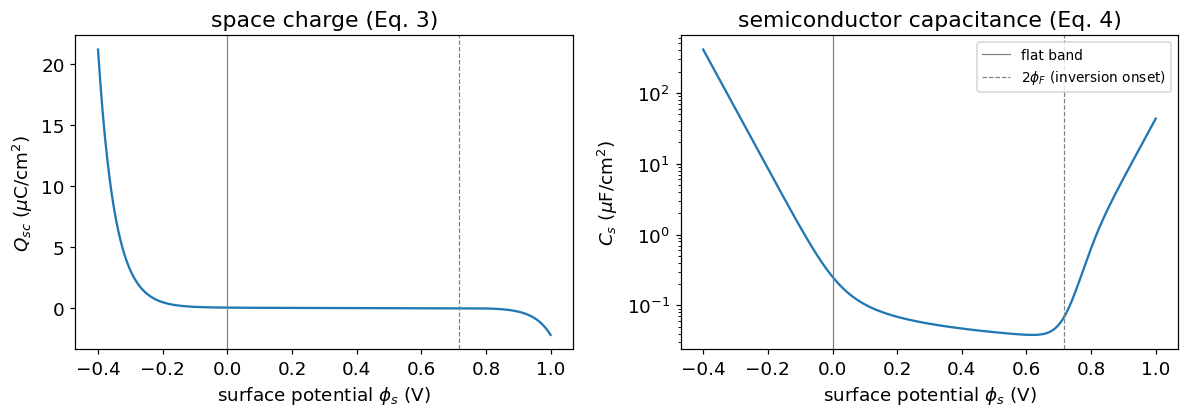

In [3]:
Na = 1e16   # p-type substrate, cm^-3
phi_s = np.linspace(-0.4, 1.0, 400)
Qsc = cgv.space_charge_density(phi_s, Na, 'p')
Cs = cgv.semiconductor_capacitance(phi_s, Na, 'p')
phiF = cgv.fermi_potential(Na, 'p')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(phi_s, Qsc*1e6)
ax1.axvline(0, color='gray', lw=0.8)
ax1.axvline(2*phiF, color='gray', ls='--', lw=0.8)
ax1.set_xlabel(r'surface potential $\phi_s$ (V)')
ax1.set_ylabel(r'$Q_{sc}$ ($\mu$C/cm$^2$)')
ax1.set_title('space charge (Eq. 3)')

ax2.semilogy(phi_s, Cs*1e6)
ax2.axvline(0, color='gray', lw=0.8, label='flat band')
ax2.axvline(2*phiF, color='gray', ls='--', lw=0.8, label=r'$2\phi_F$ (inversion onset)')
ax2.set_xlabel(r'surface potential $\phi_s$ (V)')
ax2.set_ylabel(r'$C_s$ ($\mu$F/cm$^2$)')
ax2.set_title('semiconductor capacitance (Eq. 4)')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()


$C_s$ spans nearly five decades between accumulation and depletion.
Accumulation piles up majority carriers right at the interface, so a tiny
change in $\phi_s$ moves a lot of charge - $C_s$ is huge, and the series
combination in Sec. 6 will be dominated by $C_{\text{ox}}$ alone. In
depletion, $C_s$ falls to the value set by the depletion width, which is
why the total capacitance drops as the gate is biased away from
accumulation. Past $2\phi_F$, $C_s$ turns back up as the exponentially
growing minority-carrier (inversion) charge takes over from the slowly
saturating depletion charge - and whether that turn-up shows up in a real
measurement is entirely a question of frequency, which is Sec. 5.


## 5. Why does measurement frequency change the shape of the curve?

Majority carriers respond to the AC signal in about a dielectric
relaxation time - picoseconds, effectively instantaneous. Minority
carriers in the depletion region do not exist in equilibrium; they have
to be *generated*, thermally, one electron-hole pair at a time, and that
takes a generation lifetime - microseconds to milliseconds in a
teaching-grade device. That mismatch is the whole reason C-V curves are
measured at more than one frequency:

- **High frequency (HF).** The AC signal is far too fast for minority
  carriers to generate in step with it. Past the onset of inversion, the
  inversion charge is frozen at whatever the DC bias has managed to
  accumulate over the whole sweep, and $C_s$ is clamped at its
  depletion-limited value.
- **Low frequency / quasi-static (LF).** The AC signal (or the DC ramp
  rate, if a true DC method is used instead) is slow enough that minority
  carriers keep up. The equilibrium $C_s(\phi_s)$ of Eq. (4) - inversion
  turn-up included - is measured directly.
- **Deep depletion.** The *bias sweep itself* is faster than the
  generation lifetime, so the surface never reaches equilibrium at all:
  depletion keeps growing past where it would have stopped, and $C$ falls
  below even the HF minimum.

Section 6 builds all three from the same underlying physics, differing
only in what is allowed to happen to the minority-carrier charge.


## 6. What does the ideal C-V curve look like, feature by feature?

The oxide and the semiconductor combine in series:

$$
C(V) = \frac{C_{\text{ox}}\,C_s(\phi_s(V))}{C_{\text{ox}} + C_s(\phi_s(V))}
\tag{7}
$$

with $\phi_s(V)$ found from charge balance across the structure - the
gate voltage splits between band bending and the voltage dropped across
the oxide:

$$
V_G = V_{FB} + \phi_s - \frac{Q_{sc}(\phi_s)}{C_{\text{ox}}} \tag{8}
$$

solved numerically for $\phi_s$ at each $V_G$ (`surface_potential_from_bias`).
$V_{FB}$, the flat-band voltage, is the subject of Sec. 7; take it as a
given offset for now.


C_ox            =   34.53 pF
C_min (HF)      =    3.44 pF   ratio C_min/C_ox = 0.100
C at V_FB       =   14.62 pF
V_FB = -0.90 V,  V_T = -0.04 V


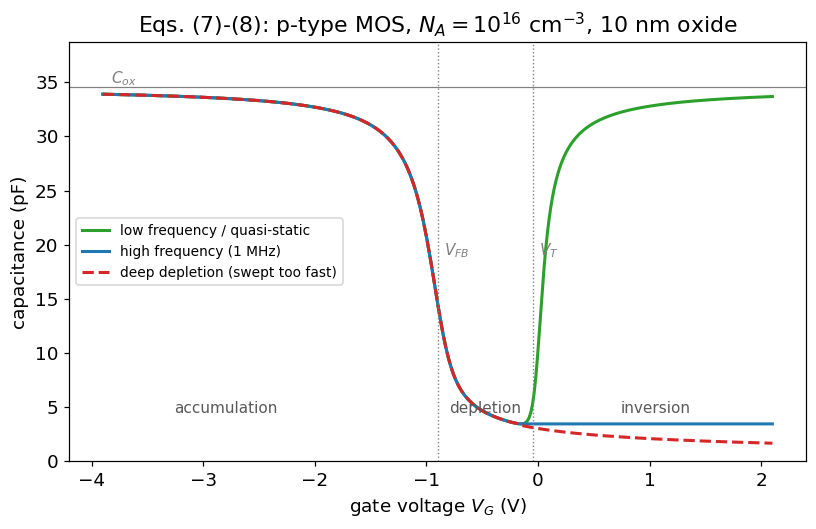

In [4]:
VFB = -0.9   # flat-band voltage, worked example
Vg = np.linspace(VFB - 3.0, VFB + 3.0, 400)

C_hf = cgv.hf_cv_curve(Vg, area_cm2, tox_nm, Na, 'p', VFB)
C_lf = cgv.lf_cv_curve(Vg, area_cm2, tox_nm, Na, 'p', VFB)
C_dd = cgv.deep_depletion_cv(Vg, area_cm2, tox_nm, Na, 'p', VFB)
VT = cgv.threshold_voltage(Cox_pa, Na, 'p', VFB)

fig, ax = plt.subplots(figsize=(7.6, 5))
ax.plot(Vg, C_lf*1e12, lw=2, color='C2', label='low frequency / quasi-static')
ax.plot(Vg, C_hf*1e12, lw=2, color='C0', label='high frequency (1 MHz)')
ax.plot(Vg, C_dd*1e12, lw=2, ls='--', color='C3',
        label='deep depletion (swept too fast)')
ax.axhline(Cox*1e12, color='gray', lw=0.8, ls='-')
ax.text(Vg[5], Cox*1e12*1.01, r'$C_{ox}$', fontsize=10, color='gray')
for x, name in ((VFB, r'$V_{FB}$'), (VT, r'$V_T$')):
    ax.axvline(x, color='gray', ls=':', lw=0.9)
    ax.annotate(name, (x, Cox*1e12*0.55), xytext=(4, 0),
                textcoords='offset points', fontsize=10, color='gray')
for x, name in ((VFB - 1.9, 'accumulation'), ((VFB + VT)/2, 'depletion'),
                (VT + 1.1, 'inversion')):
    ax.annotate(name, (x, Cox*1e12*0.13), ha='center', fontsize=10,
                color='0.35')
ax.set_ylim(0, Cox*1e12*1.12)
ax.set_xlabel(r'gate voltage $V_G$ (V)')
ax.set_ylabel('capacitance (pF)')
ax.set_title(r'Eqs. (7)-(8): p-type MOS, $N_A=10^{16}$ cm$^{-3}$, 10 nm oxide')
ax.legend(fontsize=9, loc='center left')
plt.tight_layout()
plt.show()

print(f"C_ox            = {Cox*1e12:7.2f} pF")
print(f"C_min (HF)      = {C_hf.min()*1e12:7.2f} pF   ratio C_min/C_ox = {C_hf.min()/Cox:.3f}")
print(f"C at V_FB       = {np.interp(VFB, Vg, C_hf)*1e12:7.2f} pF")
print(f"V_FB = {VFB:+.2f} V,  V_T = {VT:+.2f} V")

Three plateaus and a knee, read left to right. In strong
accumulation, all three curves sit at $C_{\text{ox}}$ (slightly below it,
because a 10 nm oxide is thin enough that accumulation does not fully
saturate - a real, literature-documented effect, not noise). Through
depletion, all three fall together, because the physics is identical
until minority carriers matter. Past the knee, they separate: HF freezes
at a minimum set by the maximum depletion width; LF rises back toward
$C_{\text{ox}}$ as the inversion layer forms in step with the sweep; and
deep depletion overshoots past the HF minimum because the surface never
gets the chance to invert at all - it is not swept too fast in *time*,
it is swept too fast relative to how slowly minority carriers generate.
Comparing the HF and LF curves at fixed bias is itself a diagnostic: any
difference beyond depletion is minority-carrier response, and its size
is a rough clock on the generation lifetime.


## 7. Where does the voltage axis sit - flat-band voltage and oxide charge?

$$
V_{FB} = \phi_{ms} - \frac{Q_{\text{eff}}}{C_{\text{ox}}} \tag{9}
$$

the metal-semiconductor work function difference $\phi_{ms}$, minus the
effective oxide charge divided by the oxide capacitance [[2]](#ref2). If
the oxide carried no charge at all, $V_{FB}$ would just be $\phi_{ms}$;
any additional shift is oxide charge, and Eq. (9) rearranges to read that
charge back off a measured curve:

$$
Q_{\text{eff}} = C_{\text{ox}}\left(\phi_{ms} - V_{FB}\right) \tag{10}
$$

**This is the section's own measured-vs-inferred moment**: $V_{FB}$ is
read directly off a curve, $Q_{\text{eff}}$ is inferred from how far that
curve has moved relative to the charge-free ideal.

To find $V_{FB}$ on a measured curve, compute the *ideal* flat-band
capacitance from the Debye length at $\phi_s=0$ - $C_s(0)=\varepsilon_s/L_D$
combined in series with $C_{\text{ox}}$ - and read off the bias where the
measured HF curve crosses it.


In [5]:
Cfb_pa = cgv.flatband_capacitance_per_area(Cox_pa, Na)
Cfb = Cfb_pa * area_cm2
i_cross = np.argmin(np.abs(C_hf - Cfb))
VFB_read = Vg[i_cross]
print(f"C_FB = {Cfb*1e12:.3f} pF")
print(f"V_FB read off the curve = {VFB_read:.3f} V  (true value: {VFB:.3f} V)")

phi_ms = -0.85
Qeff = cgv.effective_oxide_charge(phi_ms, VFB_read, Cox_pa)
Neff = Qeff / cgv.Q
print(f"phi_ms (assumed) = {phi_ms:.3f} eV")
print(f"Q_eff = {Qeff*1e9:.3f} nC/cm^2  ->  N_eff = {Neff:.3e} cm^-2")


C_FB = 14.614 pF
V_FB read off the curve = -0.892 V  (true value: -0.900 V)
phi_ms (assumed) = -0.850 eV
Q_eff = 14.669 nC/cm^2  ->  N_eff = 9.156e+10 cm^-2


## 8. Where does inversion begin - threshold voltage?

Threshold is defined as the bias at which $\phi_s$ reaches $2\phi_F$ -
the conventional onset of strong inversion:

$$
V_T = V_{FB} + s\left[\frac{\sqrt{4\varepsilon_s q N|\phi_F|}}{C_{\text{ox}}}\right]
+ s\cdot 2|\phi_F| \tag{11}
$$

with $s=+1$ for p-type ($V_T>V_{FB}$, more depletion needed to invert)
and $s=-1$ for n-type ($V_T<V_{FB}$) [[6]](#ref6). On the HF curve, $V_T$
sits close to (though not exactly at) the capacitance minimum - the true
minimum is set by where the exact $C_s(\phi_s)$ of Eq. (4) actually turns
over, which is what Sec. 4's checks locate numerically rather than assume
analytically.


V_T = -0.043 V   (V_FB = -0.900 V)


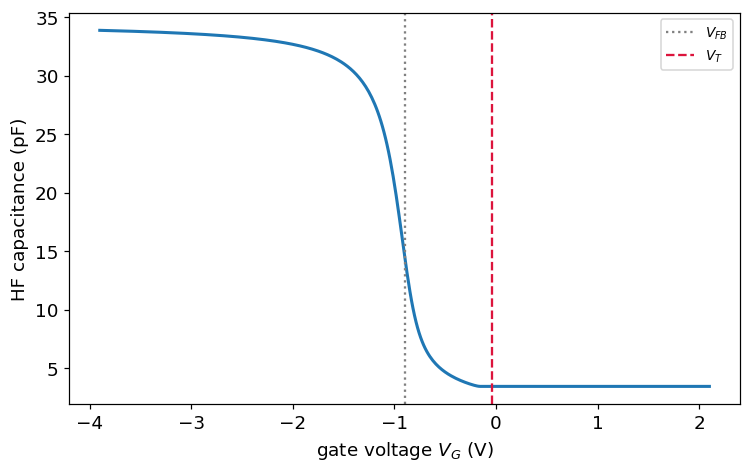

In [6]:
VT = cgv.threshold_voltage(Cox_pa, Na, 'p', VFB)
print(f"V_T = {VT:.3f} V   (V_FB = {VFB:.3f} V)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(Vg, C_hf*1e12, lw=2)
ax.axvline(VFB, color='gray', ls=':', label=r'$V_{FB}$')
ax.axvline(VT, color='crimson', ls='--', label=r'$V_T$')
ax.set_xlabel(r'gate voltage $V_G$ (V)')
ax.set_ylabel('HF capacitance (pF)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 9. How do we turn C(V) into a doping profile?

<div align="center">
   <img src="./figures/fig_cgv_doping_profile.jpg" width="680">
</div>

Differentiate the series combination and the algebra collapses to a
single working formula [[1]](#ref1):

$$
N(W) = \frac{2}{q\varepsilon_s A^2\left|d(1/C^2)/dV\right|} \tag{12}
$$

with a depth scale that comes straight from the measured capacitance
alone:

$$
W = \frac{\varepsilon_s A}{C} \tag{13}
$$

The absolute value in Eq. (12) is deliberate, and worth dwelling on: the
textbook form of this formula is usually written for a bias convention
where increasing voltage means increasing *reverse* bias, so $1/C^2$
falls as $V$ rises. The convention used throughout this notebook has
increasing $V_G$ deepen depletion directly (for p-type), the opposite
sign - so $1/C^2$ *rises* with $V_G$ here. $N(W)$ itself can never be
negative, so working with $|d(1/C^2)/dV|$ sidesteps having to track which
convention is in play. Get this wrong and the formula still runs; it just
hands back a negative doping density, which is a very easy mistake to
miss if you are not looking for it.

This is the notebook's TLM-equivalent section: a slope carries the
physics, extracted point by point from noisy data, and a naive finite
difference is a lot noisier than the underlying curve suggests. Compare a
raw finite difference against a smoothed one on the same data.


true doping                 : 3.00e+16 cm^-3
median of all points        : 3.82e+16 cm^-3
median of the valid points  : 3.38e+16 cm^-3
largest value, unmasked     : 1.65e+19 cm^-3  <- artefact
largest value, masked       : 1.78e+17 cm^-3
points discarded            : 27 of 120


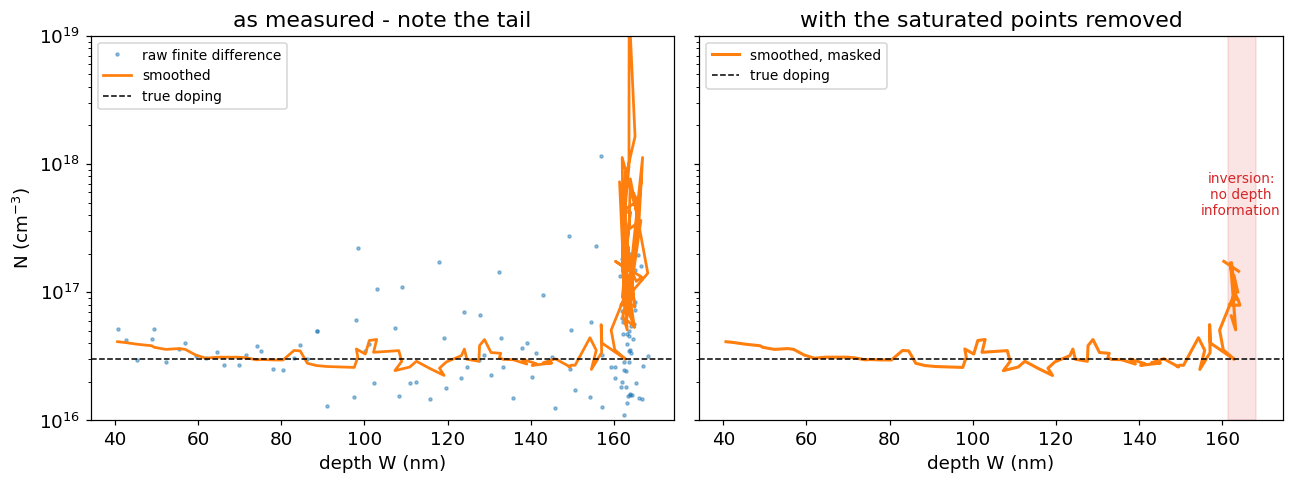

In [7]:
N_true_uniform = 3e16
VFB2 = -0.8
Vg2 = np.linspace(VFB2 + 0.1, VFB2 + 1.4, 120)
C2 = cgv.synthetic_hf_cv(Vg2, area_cm2, tox_nm, N_true_uniform, 'p', VFB2,
                         noise_frac=0.01, seed=1)

# cox_F tells the extraction to subtract the oxide from the series
# combination before turning capacitance into depth - see Eq. (13).
W_raw, N_raw = cgv.doping_profile_from_cv(Vg2, C2, area_cm2, cox_F=Cox,
                                          smooth=False, mask_invalid=False)
W_all, N_all = cgv.doping_profile_from_cv(Vg2, C2, area_cm2, cox_F=Cox,
                                          smooth=True, mask_invalid=False)
W_ok,  N_ok  = cgv.doping_profile_from_cv(Vg2, C2, area_cm2, cox_F=Cox,
                                          smooth=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
ax[0].semilogy(W_raw*1e7, N_raw, '.', ms=4, alpha=0.45, color='C0',
               label='raw finite difference')
ax[0].semilogy(W_all*1e7, N_all, lw=1.8, color='C1', label='smoothed')
ax[0].axhline(N_true_uniform, color='k', ls='--', lw=1, label='true doping')
ax[0].set_title('as measured - note the tail')
ax[1].semilogy(W_ok*1e7, N_ok, lw=2, color='C1', label='smoothed, masked')
ax[1].axhline(N_true_uniform, color='k', ls='--', lw=1, label='true doping')
ax[1].set_title('with the saturated points removed')
bad = ~np.isfinite(N_ok)
if bad.any():
    ax[1].axvspan(np.nanmin(W_all[bad])*1e7, np.nanmax(W_all[bad])*1e7,
                  color='C3', alpha=0.12)
    ax[1].text(np.nanmean(W_all[bad])*1e7, 4e17, 'inversion:\nno depth\ninformation',
               ha='center', fontsize=9, color='C3')
for a in ax:
    a.set_xlabel('depth W (nm)')
    a.legend(fontsize=9, loc='upper left')
    a.set_ylim(1e16, 1e19)
ax[0].set_ylabel(r'N (cm$^{-3}$)')
plt.tight_layout()
plt.show()

print(f"true doping                 : {N_true_uniform:.2e} cm^-3")
print(f"median of all points        : {np.nanmedian(N_all):.2e} cm^-3")
print(f"median of the valid points  : {np.nanmedian(N_ok):.2e} cm^-3")
print(f"largest value, unmasked     : {np.nanmax(N_all):.2e} cm^-3  <- artefact")
print(f"largest value, masked       : {np.nanmax(N_ok):.2e} cm^-3")
print(f"points discarded            : {bad.sum()} of {len(N_ok)}")

Uniform doping is the easy case: the answer is a horizontal line, and
any wobble in it is noise. The technique earns its keep on a profile that
is *not* uniform, because then $N(W)$ is the measurement.

Building a believable test case takes more care than it looks. The
depletion edge cannot be placed independently at each bias - it moves
continuously, and the gate voltage has to account for the charge already
uncovered. Integrating Poisson twice over an arbitrary $N(x)$ gives both:

$$
Q_{dep}(W) = q\int_0^W N(x)\,dx,
\qquad
\phi_s(W) = \frac{q}{\varepsilon_s}\int_0^W x\,N(x)\,dx \tag{14}
$$

and then $V_G = V_{FB} + \phi_s + Q_{dep}/C_{ox}$ as before. The second
integral is the depth-weighted first moment of the profile: charge
further from the surface costs more band bending, which is exactly why a
non-uniform profile is recoverable at all. `cv_from_depth_profile` does
this.

true peak     : 9.00e+16 cm^-3 at 60 nm
recovered peak: 9.12e+16 cm^-3 at 64 nm
true substrate: 2.00e+16 cm^-3
recovered deep: 1.95e+16 cm^-3


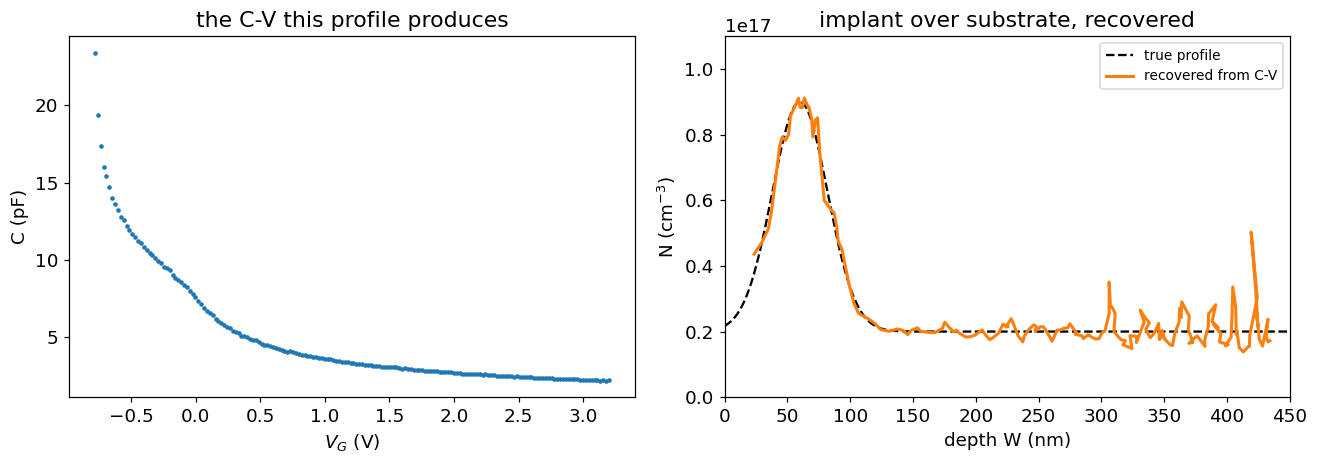

In [8]:
# a Gaussian implant sitting on a lightly doped substrate
depth = np.linspace(0, 6e-5, 8000)            # 0 - 600 nm, in cm
Rp, dRp = 6e-6, 2.2e-6                        # 60 nm projected range, 22 nm straggle
N_sub, N_peak = 2e16, 7e16
N_profile = N_sub + N_peak*np.exp(-0.5*((depth - Rp)/dRp)**2)

V_nu, C_nu = cgv.cv_from_depth_profile(depth, N_profile, area_cm2, tox_nm,
                                       'p', VFB2)

# sample it the way an instrument would, and add 0.5% noise
V_meas = np.linspace(V_nu.min() + 0.02, min(V_nu.max(), VFB2 + 4.0), 180)
C_meas = np.interp(V_meas, V_nu, C_nu)
C_meas = C_meas*(1 + np.random.default_rng(2).normal(0, 0.005, C_meas.shape))

W_ex, N_ex = cgv.doping_profile_from_cv(V_meas, C_meas, area_cm2,
                                        cox_F=Cox, smooth=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].plot(V_meas, C_meas*1e12, '.', ms=4, color='C0')
ax[0].set_xlabel(r'$V_G$ (V)'); ax[0].set_ylabel('C (pF)')
ax[0].set_title('the C-V this profile produces')

ok = np.isfinite(N_ex) & np.isfinite(W_ex) & (W_ex > 1.5e-6)
ax[1].plot(depth*1e7, N_profile, 'k--', lw=1.5, label='true profile')
ax[1].plot(W_ex[ok]*1e7, N_ex[ok], lw=2, color='C1', label='recovered from C-V')
ax[1].set_xlim(0, 450); ax[1].set_ylim(0, 1.1e17)
ax[1].set_xlabel('depth W (nm)'); ax[1].set_ylabel(r'N (cm$^{-3}$)')
ax[1].set_title('implant over substrate, recovered')
ax[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

pk = W_ex[ok][np.argmax(N_ex[ok])]
print(f"true peak     : {N_profile.max():.2e} cm^-3 at {Rp*1e7:.0f} nm")
print(f"recovered peak: {np.nanmax(N_ex[ok]):.2e} cm^-3 at {pk*1e7:.0f} nm")
print(f"true substrate: {N_sub:.2e} cm^-3")
print(f"recovered deep: {np.nanmedian(N_ex[ok][W_ex[ok] > 2.5e-5]):.2e} cm^-3")

The peak comes back in the right place and close to the right height,
and the substrate level is recovered beyond it. Two caveats worth
carrying away.

**The shallow end is missing.** Nothing is recovered inside about 40 nm,
because the depletion edge is never there: at flat band the surface is
already depleted to a fraction of a Debye length, and the sweep can only
push the edge outwards. C-V profiling cannot see the first few tens of
nanometres, which is exactly where an implant peak often sits.

**The recovered peak is lower and broader than the truth.** Part of that
is the smoothing filter, but the physical limit is the Debye length,
about 40 nm at $2\times10^{16}$ cm$^{-3}$: majority carriers cannot
follow a doping change faster than that, so the measured profile is the
true one blurred over roughly $3\lambda_D$. The depletion approximation
used in Eq. (14) does not model that blurring, so the agreement here is
slightly better than a real measurement would give. Eq. (5) is the
relevant length.

## 10. What happens without an oxide? Schottky C-V and the Mott-Schottky line

Set $C_{\text{ox}}\to\infty$ in Eqs. (7) and (12) - no series oxide
element at all, a bare metal-semiconductor (Schottky) junction - and the
general result collapses to the classic **Mott-Schottky** line:

$$
\frac{1}{C^2} = \frac{2(V_{bi}-V)}{q\varepsilon_s A^2 N} \tag{15}
$$

linear in $V$: the slope gives $N$, the intercept on the voltage axis
gives the built-in potential $V_{bi}$ [[1]](#ref1). This is deliberately
the same payoff KPSPV gives when SPV falls out of the CPD machinery as a
special case - a general result specialising to a simpler, more famous
one. It is also, structurally, the same fit TLM makes: a straight line
whose slope is well-constrained by the data and whose intercept is a more
fragile extrapolation.

The important check is that this is an *algebraic identity*, not a
numerical coincidence - the same helper code that builds the MOS curves
above, with `Cox_pa` set enormous, reproduces Eq. (15) exactly
(`cgv_helper_checks.py`, check 10).


N (true)   = 3.000e+16 cm^-3
N (fit)    = 3.013e+16 +/- 3.3e+14 cm^-3  (1.1%)
Vbi (true) = 0.750 V
Vbi (fit)  = 0.767 +/- 0.053 V  (7.1%)


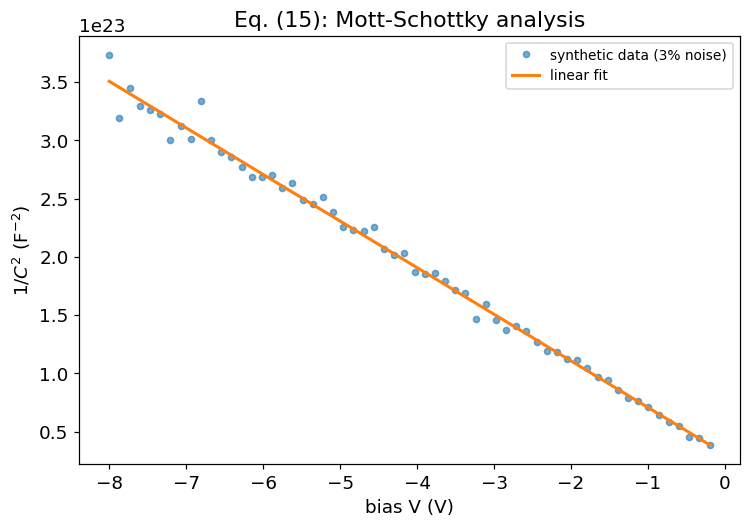

In [9]:
N_schottky = 3e16
Vbi_true = 0.75
V_ms = np.linspace(-8, -0.2, 60)
C_ms = cgv.synthetic_mott_schottky(V_ms, N_schottky, Vbi_true, area_cm2, noise_frac=0.03, seed=3)

N_fit, N_fit_err, Vbi_fit, Vbi_fit_err = cgv.mott_schottky_fit(V_ms, C_ms, area_cm2)
print(f"N (true)   = {N_schottky:.3e} cm^-3")
print(f"N (fit)    = {N_fit:.3e} +/- {N_fit_err:.1e} cm^-3  ({100*N_fit_err/N_fit:.1f}%)")
print(f"Vbi (true) = {Vbi_true:.3f} V")
print(f"Vbi (fit)  = {Vbi_fit:.3f} +/- {Vbi_fit_err:.3f} V  ({100*Vbi_fit_err/Vbi_true:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(V_ms, 1/C_ms**2, 'o', ms=4, alpha=0.6, label='synthetic data (3% noise)')
fit_line = 2*(Vbi_fit - V_ms)/(cgv.Q*cgv.EPS_SI*area_cm2**2*N_fit)
ax.plot(V_ms, fit_line, lw=2, label='linear fit')
ax.set_xlabel('bias V (V)')
ax.set_ylabel(r'$1/C^2$ (F$^{-2}$)')
ax.set_title('Eq. (15): Mott-Schottky analysis')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


$N$ comes back to within a percent or two of the noise level; $V_{bi}$,
extrapolated out to where the line crosses zero, carries a noticeably
larger relative uncertainty for the same input noise - the slope is
constrained by every point on the line, the intercept only by how far you
have to extrapolate to reach it. Exactly the TLM lesson, in a different
notebook.


## 11. What is the conductance method actually measuring?

<div align="center">
   <img src="./figures/fig_cgv_conductance_method.jpg" width="680">
</div>

Interface states sit at energy levels inside the silicon band gap, right
at the oxide interface. At a given bias, states near the Fermi level
capture and emit carriers on some characteristic timescale $\tau_{it}$.
When the AC signal's angular frequency $\omega$ is comparable to
$1/\tau_{it}$, the traps cannot quite keep up: their charging lags the
signal, and that lag dissipates energy. A genuine loss mechanism - it
shows up in $G$, the out-of-phase component, not in $C$.

The measured admittance at any one bias and frequency is

$$
Y_m = G_m + j\omega C_m \tag{16}
$$

[[3]](#ref3). Sweep frequency at fixed bias, and the interface-trap
signature is a peak in $G_m/\omega$ - but only *after* removing the
series oxide capacitance from the circuit, which is Sec. 12.


## 12. How do we get the semiconductor's true parallel conductance out of what the meter reports?

<div align="center">
   <img src="./figures/fig_cgv_equivalent_circuit.jpg" width="680">
</div>

$C_{\text{ox}}$ still sits in series with the semiconductor branch in the
equivalent circuit, so the raw $G_m/\omega$ is not yet the quantity that
peaks cleanly with interface-trap physics. Converting the measured
admittance through the known $C_{\text{ox}}$ gives the semiconductor
branch's true parallel conductance [[3]](#ref3):

$$
\frac{G_p}{\omega} = \frac{\omega C_{\text{ox}}^2 G_m}
{G_m^2 + \omega^2(C_{\text{ox}}-C_m)^2} \tag{17}
$$

Skipping this step, or using an inaccurate $C_{\text{ox}}$, is the single
biggest source of a wrong $D_{it}$ - the error in $C_{\text{ox}}$ propagates
directly into Eq. (17) and from there directly into everything Sec. 13
extracts.


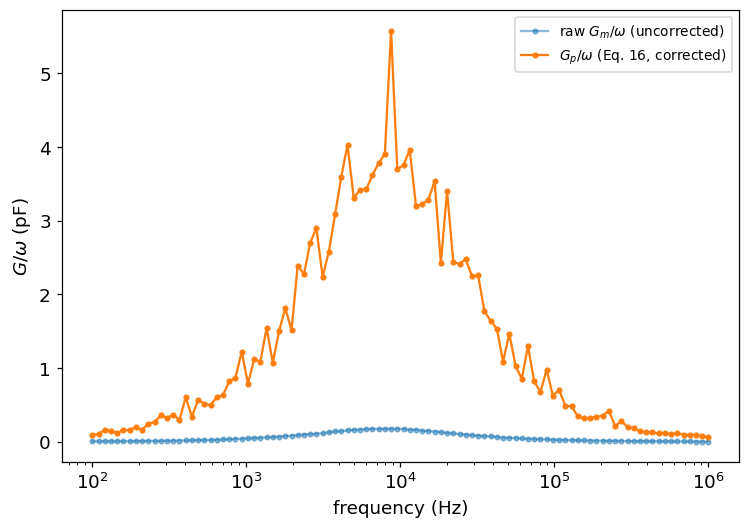

In [10]:
Dit_true = 5e11    # cm^-2 (areal density, single-level teaching model)
tau_it_true = 2e-5  # s
freqs = np.logspace(2, 6, 100)
Cm, Gm = cgv.synthetic_conductance_sweep(
    freqs, Dit_true, tau_it_true, area_cm2, tox_nm, noise_frac=0.02, seed=4)
omega = 2*np.pi*freqs
Gp_over_w = cgv.admittance_to_parallel(Cm, Gm, omega, Cox)

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(freqs, Gm/omega*1e12, 'o-', ms=3, alpha=0.5, label=r'raw $G_m/\omega$ (uncorrected)')
ax.semilogx(freqs, Gp_over_w*1e12, 'o-', ms=3, label=r'$G_p/\omega$ (Eq. 16, corrected)')
ax.set_xlabel('frequency (Hz)')
ax.set_ylabel(r'$G/\omega$ (pF)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


The corrected curve peaks at a lower frequency and a higher value
than the raw one - the series $C_{\text{ox}}$ shortens the semiconductor
branch's effective time constant when left uncorrected, exactly as
Sec. 12 warns. Only the corrected curve is the one Sec. 13 fits.


## 13. What does the conductance peak tell us about interface traps?

The simplest possible model - a single interface-trap energy level, no
spread in time constant - gives a Lorentzian peak [[3]](#ref3):

$$
\frac{G_p}{\omega} = qD_{it}A\,\frac{\omega\tau_{it}}{1+(\omega\tau_{it})^2}
\tag{18}
$$

peaking exactly at $\omega\tau_{it}=1$ with height $qD_{it}A/2$. The time
constant itself is set by the capture rate:

$$
\tau_p = \frac{1}{c_pN_A} \tag{19}
$$

with $c_p=\sigma_pv_{th}$ the capture probability [[3]](#ref3).

**Eq. (18) is a teaching-grade starting point, not the full story.** Real
interface traps are spread over a continuum of energies, and real
surfaces have patch-to-patch band-bending fluctuations - both broaden and
lower the measured peak relative to what Eq. (18) predicts
[[3]](#ref3)[[2]](#ref2). Nicollian and Brews give the full statistical
treatment (a Gaussian average over band-bending fluctuations, their
Eqs. 5.70-5.85); illustrating the effect without implementing that full
double integral, superpose a spread of single-level peaks and watch the
sum broaden and flatten relative to any one of them.


D_it (true) = 5.000e+11 cm^-2
D_it (fit)  = 5.407e+11 cm^-2  (8.1% off)
tau_it (true) = 2.00e-05 s
tau_it (fit)  = 1.83e-05 s


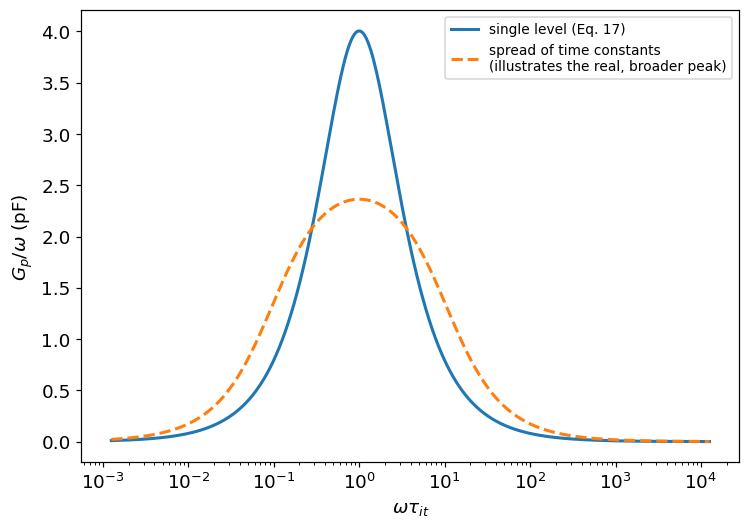

In [11]:
Dit_fit, tau_fit = cgv.fit_dit_from_peak(omega, Gp_over_w, area_cm2)
print(f"D_it (true) = {Dit_true:.3e} cm^-2")
print(f"D_it (fit)  = {Dit_fit:.3e} cm^-2  ({100*abs(Dit_fit-Dit_true)/Dit_true:.1f}% off)")
print(f"tau_it (true) = {tau_it_true:.2e} s")
print(f"tau_it (fit)  = {tau_fit:.2e} s")

# Illustrate broadening: superpose single-level peaks over a spread of tau
omega_grid = 2*np.pi*np.logspace(1, 8, 400)
taus = np.geomspace(tau_it_true/8, tau_it_true*8, 9)
single = cgv.conductance_lorentzian(omega_grid, Dit_true, tau_it_true, area_cm2)
broadened = np.mean(
    [cgv.conductance_lorentzian(omega_grid, Dit_true, t, area_cm2) for t in taus], axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(omega_grid*tau_it_true, single*1e12, lw=2, label='single level (Eq. 17)')
ax.semilogx(omega_grid*tau_it_true, broadened*1e12, lw=2, ls='--',
            label='spread of time constants\n(illustrates the real, broader peak)')
ax.set_xlabel(r'$\omega\tau_{it}$')
ax.set_ylabel(r'$G_p/\omega$ (pF)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


The broadened curve peaks lower and wider than the single-level
model, for the same total trap density - reading $D_{it}$ off Eq. (18)'s
peak-height formula when the real peak is this broadened would
underestimate $D_{it}$. This is exactly the caution Nicollian and Brews
give: the width of a measured $G_p/\omega$ curve is itself information
(about the spread of band-bending fluctuations across the surface, i.e.
about surface uniformity), not just noise to average away.


## 14. How would you compute a C-V curve from scratch?

Everything so far has taken $C_s(\phi_s)$ as given by Eq. (4), which was
derived with Boltzmann statistics and fully ionised dopants. Both
assumptions are good for moderately doped silicon at room temperature and
both fail predictably: Boltzmann statistics overestimate the carrier
density once the Fermi level approaches a band edge, and shallow dopants
are not fully ionised at high concentration.

This section and the next three set the shortcuts aside and build the
curve the way you would if you had to compute it properly. The chain is:

1. solve bulk charge neutrality for $E_F$,
2. pick a surface potential $\phi_s$ and get the carrier densities there,
3. integrate Poisson once to get $Q_s$,
4. differentiate to get $C_s$,
5. balance the charge across the structure to get the $V_G$ that produced
   that $\phi_s$,
6. sweep $\phi_s$ and plot.

Note the direction. Sec. 6 solved Eq. (8) *for* $\phi_s$ at each $V_G$,
which needs a root find at every point. Sweeping $\phi_s$ instead makes
every quantity an explicit function of it, and the curve comes out
parametrically with no root finding at all.

**Carrier densities.** With Fermi-Dirac statistics the densities are
Fermi integrals rather than exponentials:

$$
n = N_c\,\mathcal{F}_{1/2}\!\left(\frac{E_F-E_c}{kT}\right),
\qquad
p = N_v\,\mathcal{F}_{1/2}\!\left(\frac{E_v-E_F}{kT}\right) \tag{20}
$$

$$
\mathcal{F}_j(\eta) = \frac{1}{\Gamma(j+1)}
\int_0^\infty \frac{\epsilon^j}{1+e^{\epsilon-\eta}}\,d\epsilon \tag{21}
$$

normalised so that $\mathcal{F}_j(\eta)\to e^{\eta}$ when
$\eta \ll 0$, which recovers Eq. (2)'s Boltzmann form exactly.

**Ionisation.** A dopant atom is only charged when its level is empty
(donor) or full (acceptor), and that occupancy depends on where $E_F$ sits
relative to the level:

$$
N_A^- = \frac{N_A}{1+g_a\exp\!\left(\frac{E_A-E_F}{kT}\right)},
\qquad
N_D^+ = \frac{N_D}{1+g_d\exp\!\left(\frac{E_F-E_D}{kT}\right)} \tag{22}
$$

**Neutrality.** The bulk must be neutral, which fixes $E_F$:

$$
N_D^+ - N_A^- + p - n = 0 \tag{23}
$$

N_A = 1.0e+16 cm^-3
  E_F - E_i        = -0.35212 eV   (Fermi-Dirac, Eq. 23)
  -phi_F Boltzmann = -0.35808 eV   (Eq. 2)
  difference       = 6.0 meV
  p = 9.9634e+15,  n = 1.3574e+04 cm^-3
  ionised acceptors: 99.63 %


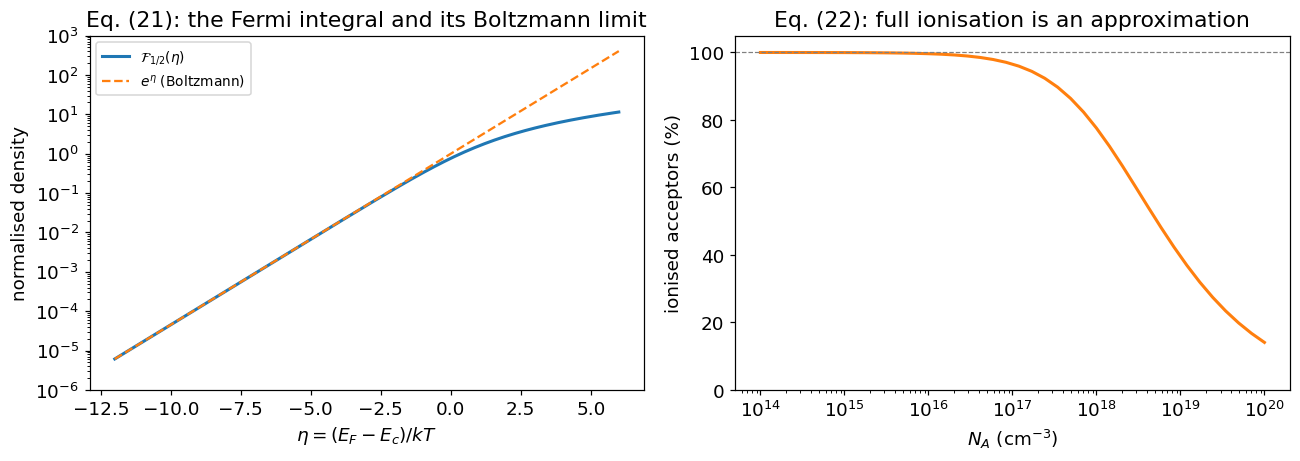

In [12]:
NA_demo = 1e16

Ef = cgv.bulk_fermi_level(NA_demo, 0.0)          # Eq. (23)
n_b, p_b = cgv.carrier_densities_fd(Ef)          # Eq. (20)
NA_ion, _ = cgv.ionised_dopants(Ef, NA_demo, 0.0)  # Eq. (22)

print(f"N_A = {NA_demo:.1e} cm^-3")
print(f"  E_F - E_i        = {Ef:+.5f} eV   (Fermi-Dirac, Eq. 23)")
print(f"  -phi_F Boltzmann = {-cgv.fermi_potential(NA_demo,'p'):+.5f} eV   (Eq. 2)")
print(f"  difference       = {abs(Ef + cgv.fermi_potential(NA_demo,'p'))*1e3:.1f} meV")
print(f"  p = {p_b:.4e},  n = {n_b:.4e} cm^-3")
print(f"  ionised acceptors: {NA_ion/NA_demo*100:.2f} %")

eta = np.linspace(-12, 6, 200)
F_half = cgv.fermi_dirac_integral(0.5, eta)      # Eq. (21)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].semilogy(eta, F_half, lw=2, label=r'$\mathcal{F}_{1/2}(\eta)$')
ax[0].semilogy(eta, np.exp(eta), '--', lw=1.5, label=r'$e^{\eta}$ (Boltzmann)')
ax[0].set_xlabel(r'$\eta = (E_F-E_c)/kT$'); ax[0].set_ylabel('normalised density')
ax[0].set_title('Eq. (21): the Fermi integral and its Boltzmann limit')
ax[0].legend(fontsize=9); ax[0].set_ylim(1e-6, 1e3)

Nd = np.logspace(14, 20, 40)
frac = [cgv.ionised_dopants(cgv.bulk_fermi_level(N, 0.0), N, 0.0)[0]/N for N in Nd]
ax[1].semilogx(Nd, np.array(frac)*100, lw=2, color='C1')
ax[1].axhline(100, color='gray', ls='--', lw=0.8)
ax[1].set_xlabel(r'$N_A$ (cm$^{-3}$)'); ax[1].set_ylabel('ionised acceptors (%)')
ax[1].set_title('Eq. (22): full ionisation is an approximation')
ax[1].set_ylim(0, 105)
plt.tight_layout(); plt.show()

Two things to take from this.

**The Boltzmann shortcut is good where we have been using it.** At
$10^{16}$ cm$^{-3}$ the Fermi level differs by about 6 meV from
$-\phi_F = -V_t\ln(N_A/n_i)$, and 99.6% of the acceptors are ionised.
Nothing in Secs. 1-13 is materially wrong.

**It stops being good exactly where devices get interesting.** By
$10^{19}$ cm$^{-3}$ only about 40% of the acceptors are ionised, and
$\mathcal{F}_{1/2}$ has fallen a factor of twenty below $e^{\eta}$. A
heavily doped substrate, a poly-Si gate, or the peak of an implant all
sit in that regime, and a C-V analysis that assumes $N = N_A$ there is
reading the wrong number.

## 15. What does the space charge look like without the Boltzmann shortcut?

With the densities in hand, integrating Poisson's equation once from the
neutral bulk to the surface gives the surface field, and Gauss's law turns
that into the charge:

$$
\xi_s^2 = \frac{2q}{\varepsilon_s}
\int_0^{\phi_s}\left[\,n(\phi) - p(\phi) - N_D^+(\phi) + N_A^-(\phi)\,\right]d\phi,
\qquad Q_s = -\varepsilon_s\,\xi_s \tag{24}
$$

Every term inside the integral is a function of the local band bending
$\phi$, because bending the bands shifts each band edge and each dopant
level relative to the fixed $E_F$. Eq. (3) is what this collapses to when
the two Fermi integrals become exponentials and the dopants are taken as
fully ionised.

The capacitance is the derivative, with the same minus sign as Eq. (4):

$$
C_s = -\frac{dQ_s}{d\phi_s} \tag{25}
$$

and this is where the high-frequency distinction of Sec. 5 becomes a
concrete instruction rather than a description: **at high frequency the
minority carriers are dropped from the derivative**, because they cannot
be generated fast enough to follow the AC signal. They are *not* dropped
from $Q_s$ itself, which is a DC quantity and sets the bias point. Freeze
them in both places and the inversion branch comes out wrong.

phi_s = -0.20 V:  Q_s(FD) = +4.1813e-07,  Q_s(Boltz) = +4.4247e-07   (  5.5 % apart)
phi_s = +0.20 V:  Q_s(FD) = -2.4044e-08,  Q_s(Boltz) = -2.4044e-08   (  0.0 % apart)
phi_s = +0.60 V:  Q_s(FD) = -4.3673e-08,  Q_s(Boltz) = -4.3668e-08   (  0.0 % apart)
phi_s = +0.80 V:  Q_s(FD) = -7.5936e-08,  Q_s(Boltz) = -6.9049e-08   ( 10.0 % apart)


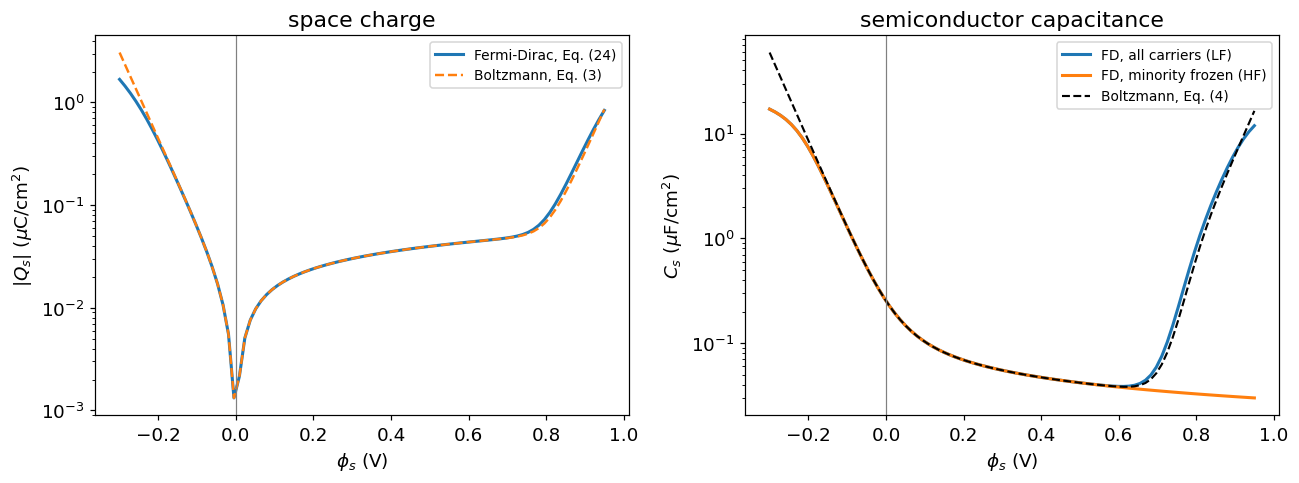

In [13]:
phi_grid = np.linspace(-0.30, 0.95, 90)

Qs_fd = cgv.space_charge_density_fd(phi_grid, NA_demo, 0.0)        # Eq. (24)
Qs_bz = cgv.space_charge_density(phi_grid, NA_demo, 'p')           # Eq. (3)
Cs_lf = cgv.semiconductor_capacitance_fd(phi_grid, NA_demo, 0.0)   # Eq. (25)
Cs_hf = cgv.semiconductor_capacitance_fd(phi_grid, NA_demo, 0.0,
                                         minority_frozen=True)
Cs_bz = cgv.semiconductor_capacitance(phi_grid, NA_demo, 'p')      # Eq. (4)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].semilogy(phi_grid, np.abs(Qs_fd)*1e6, lw=2, label='Fermi-Dirac, Eq. (24)')
ax[0].semilogy(phi_grid, np.abs(Qs_bz)*1e6, '--', lw=1.6,
               label='Boltzmann, Eq. (3)')
ax[0].axvline(0, color='gray', lw=0.8)
ax[0].set_xlabel(r'$\phi_s$ (V)'); ax[0].set_ylabel(r'$|Q_s|$ ($\mu$C/cm$^2$)')
ax[0].set_title('space charge'); ax[0].legend(fontsize=9)

ax[1].semilogy(phi_grid, Cs_lf*1e6, lw=2, label='FD, all carriers (LF)')
ax[1].semilogy(phi_grid, Cs_hf*1e6, lw=2, label='FD, minority frozen (HF)')
ax[1].semilogy(phi_grid, Cs_bz*1e6, '--', lw=1.4, color='k',
               label='Boltzmann, Eq. (4)')
ax[1].axvline(0, color='gray', lw=0.8)
ax[1].set_xlabel(r'$\phi_s$ (V)'); ax[1].set_ylabel(r'$C_s$ ($\mu$F/cm$^2$)')
ax[1].set_title('semiconductor capacitance'); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

for ps in (-0.20, 0.20, 0.60, 0.80):
    qf = float(cgv.space_charge_density_fd(ps, NA_demo, 0.0)[0])
    qb = float(np.atleast_1d(cgv.space_charge_density(ps, NA_demo, 'p'))[0])
    print(f"phi_s = {ps:+.2f} V:  Q_s(FD) = {qf:+.4e},  Q_s(Boltz) = {qb:+.4e}"
          f"   ({abs(qf/qb-1)*100:5.1f} % apart)")

In depletion the two curves lie on top of each other - the charge there is
ionised dopants, and the statistics of the free carriers barely matter.
They separate at both ends, and for the same reason in each case: the
surface has become degenerate, and the Boltzmann exponential overestimates
how many carriers are really there. In accumulation at $-0.2$ V the
Boltzmann charge is about 6% too high; in strong inversion at $+0.8$ V,
about 10%.

The right-hand panel shows the high-frequency freeze doing its job. Below
threshold the three curves agree. Past it the low-frequency curve turns
sharply upward as the inversion layer forms, while the high-frequency
curve stays flat - the same $C_{min}$ plateau seen in every measured HF
C-V curve, here produced by dropping one term from a derivative rather
than by asserting it.

## 16. Putting it together: the full gate-voltage balance

Step 5 of the procedure is a charge balance across the whole structure.
Everything the gate has to mirror - the semiconductor charge, the charge
trapped at the interface, and the fixed charge inside the oxide - shows up
as a shift of the voltage axis:

$$
V_G = \frac{\Phi_{ms}}{q} + \phi_s
      - \frac{Q_s + Q_{it} + \left(1+\frac{d}{t_i}\right)Q_f}{C_i} \tag{26}
$$

Eq. (9) is this equation with $Q_{it}$ and $Q_s$ folded into a single
$Q_{eff}$ and evaluated at flat band. Written out, two things it hides
become visible.

**The centroid factor.** $d$ is the position of the fixed charge measured
from the oxide-semiconductor interface towards the gate, running from $0$
to $-t_i$. The weight $(1+d/t_i)$ is therefore 1 for charge sitting right
at the semiconductor surface and 0 for charge at the gate. **Fixed charge
only shifts the curve to the extent that it is separated from the
semiconductor.** Charge at the interface still bends the bands, but it
contributes nothing to $V_G$; charge at the gate does nothing at all. This
is the same centroid weighting that governs how much a given $Q_f$ moves a
Kelvin probe reading.

**$Q_{it}$ moves as the bands bend.** Interface traps charge and discharge
as $E_F$ sweeps past them at the surface, so $Q_{it}$ is a function of
$\phi_s$, not a constant. With donor-like states in the lower half of the
gap and acceptor-like states in the upper half:

$$
Q_{it} = q\!\int_{E_v}^{E_c}\! D_{it}^{d}(E)\,f_d(E)\,dE
       - q\!\int_{E_v}^{E_c}\! D_{it}^{a}(E)\,\bigl(1-f_d(E)\bigr)\,dE \tag{27}
$$

with the occupancy from Shockley-Read-Hall statistics evaluated with the
*surface* densities:

$$
f_d = \frac{(\sigma_n/\sigma_p)\,n_1 + p_s}
           {(\sigma_n/\sigma_p)(n_s+n_1) + (p_s+p_1)} \tag{28}
$$

That $\phi_s$-dependence is what stretches a measured C-V curve out along
the voltage axis: charge going into traps has to be supplied by the gate
too, so more voltage is needed for the same band bending.

Q_f = 1e12 cm^-2 on C_ox = 0.345 uF/cm^2
  ideal curve crosses C_ox/2 at            -0.942 V
  charge at the Si interface (d=0)         -0.464 V shift
  same charge at 0.9 t_i from the interface-0.046 V shift
  textbook Q_f/C_ox                        -0.464 V

  D_it stretch: 90%-to-10% of C_ox takes 1.333 V ideal, 1.872 V with traps
  Q_it swings -1.19e+12 .. 1.24e+12 q/cm^2 across the sweep


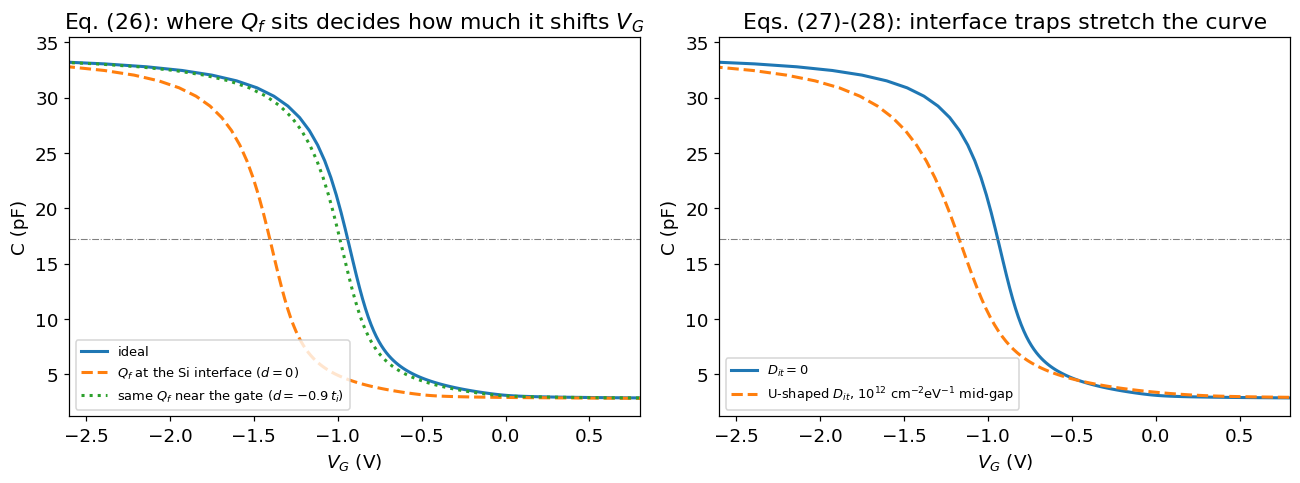

In [14]:
phi_cv = np.linspace(-0.32, 0.95, 110)
phi_ms = -0.9

def half_c_voltage(V, C, C_half):
    """the gate voltage at which the curve crosses C_half - a robust,
    monotonic way to measure how far a curve has shifted."""
    o = np.argsort(C)
    return np.interp(C_half, C[o], V[o])

Vg_id, C_id, _, _, _ = cgv.cv_curve_fd(phi_cv, area_cm2, tox_nm, NA_demo, 0.0,
                                       phi_ms_eV=phi_ms, high_frequency=True)

# 1e12 cm^-2 of positive fixed charge - a poor oxide, not a clean one
Qf = 1e12*cgv.Q
Vg_s, C_s, _, _, _ = cgv.cv_curve_fd(phi_cv, area_cm2, tox_nm, NA_demo, 0.0,
                                     phi_ms_eV=phi_ms, Qf_C_cm2=Qf,
                                     centroid_cm=0.0, high_frequency=True)
Vg_g, C_g, _, _, _ = cgv.cv_curve_fd(phi_cv, area_cm2, tox_nm, NA_demo, 0.0,
                                     phi_ms_eV=phi_ms, Qf_C_cm2=Qf,
                                     centroid_cm=-0.9*tox_nm*1e-7,
                                     high_frequency=True)

# a bad interface: U-shaped D_it, donor-like below mid-gap, acceptor-like above
Eg = cgv.EG_SI_EV
def dit_shape(E, mid=1e12, edge=1e13, tail=0.15):
    E = np.asarray(E, float)
    return mid*(edge/mid)**np.exp(-np.minimum(E, Eg-E)/tail)
d_don = lambda E: np.where(np.asarray(E) < Eg/2, dit_shape(E), 0.0)
d_acc = lambda E: np.where(np.asarray(E) >= Eg/2, dit_shape(E), 0.0)
Vg_it, C_it_, _, _, Qit = cgv.cv_curve_fd(phi_cv, area_cm2, tox_nm, NA_demo,
                                          0.0, phi_ms_eV=phi_ms,
                                          Dit_donor=d_don, Dit_acceptor=d_acc,
                                          high_frequency=True)

C_half = 0.5*Cox
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].plot(Vg_id, C_id*1e12, lw=2, label='ideal')
ax[0].plot(Vg_s, C_s*1e12, lw=2, ls='--',
           label=r'$Q_f$ at the Si interface ($d=0$)')
ax[0].plot(Vg_g, C_g*1e12, lw=2, ls=':',
           label=r'same $Q_f$ near the gate ($d=-0.9\,t_i$)')
ax[0].set_title(r'Eq. (26): where $Q_f$ sits decides how much it shifts $V_G$')

ax[1].plot(Vg_id, C_id*1e12, lw=2, label=r'$D_{it}=0$')
ax[1].plot(Vg_it, C_it_*1e12, lw=2, ls='--',
           label=r'U-shaped $D_{it}$, $10^{12}$ cm$^{-2}$eV$^{-1}$ mid-gap')
ax[1].set_title('Eqs. (27)-(28): interface traps stretch the curve')
for a in ax:
    a.set_xlim(-2.6, 0.8); a.set_xlabel(r'$V_G$ (V)'); a.set_ylabel('C (pF)')
    a.axhline(C_half*1e12, color='gray', lw=0.7, ls='-.')
    a.legend(fontsize=8.5, loc='lower left')
plt.tight_layout(); plt.show()

v0 = half_c_voltage(Vg_id, C_id, C_half)
print(f"Q_f = 1e12 cm^-2 on C_ox = {Cox_pa*1e6:.3f} uF/cm^2")
print(f"  ideal curve crosses C_ox/2 at            {v0:+.3f} V")
print(f"  charge at the Si interface (d=0)         {half_c_voltage(Vg_s,C_s,C_half)-v0:+.3f} V shift")
print(f"  same charge at 0.9 t_i from the interface{half_c_voltage(Vg_g,C_g,C_half)-v0:+.3f} V shift")
print(f"  textbook Q_f/C_ox                        {-Qf/Cox_pa:+.3f} V")
print(f"\n  D_it stretch: 90%-to-10% of C_ox takes "
      f"{abs(half_c_voltage(Vg_id,C_id,0.9*Cox)-half_c_voltage(Vg_id,C_id,0.1*Cox)):.3f} V ideal, "
      f"{abs(half_c_voltage(Vg_it,C_it_,0.9*Cox)-half_c_voltage(Vg_it,C_it_,0.1*Cox)):.3f} V with traps")
print(f"  Q_it swings {Qit.min()/cgv.Q:.2e} .. {Qit.max()/cgv.Q:.2e} q/cm^2 across the sweep")

The left panel makes the centroid concrete. The *same*
$10^{12}$ cm$^{-2}$ of positive charge shifts the curve by about half a
volt when it sits against the silicon, and by a tenth of that when it sits
against the gate. The full shift matches the textbook $Q_f/C_{ox}$ only in
the first case, which is the case that expression silently assumes. An
extracted $Q_{\text{eff}}$ from Eq. (10) is really the product
$Q_f(1+d/t_i)$, and a C-V measurement on its own cannot separate the two -
the same ambiguity a Kelvin probe has.

The right panel shows the trap stretch. The curve is not shifted so much
as *sheared*: in depletion, where $E_F$ is sweeping through the middle of
the gap, the traps charge and discharge and absorb gate charge, so more
volts are needed per volt of band bending. The accumulation-to-inversion
transition is drawn out measurably. That stretch is the C-V signature of a
bad interface, and quantifying it is what the Terman method does - though
the conductance method of Secs. 11-13 is more sensitive, because it
measures the *loss* rather than a distortion of the shape.

## 17. What if the charge is not uniform, and what the full trap admittance looks like

Two loose ends from the model above, both of which matter on real films.

**Fixed charge is not uniform across the gate.** A dielectric deposited
over a wafer has a distribution of $Q_f$, not a single value, and a
large-area gate averages over it. Sampling $Q_f' = Q_f + \Delta q$ from a
Gaussian and re-solving Eq. (26) for each sample gives a distribution
$P(\phi_s)$ at every bias, and the measured curve is the average over it.
The visible effect is a smearing of every feature - and, importantly, it
looks exactly like a higher $D_{it}$, which is the trap.

**The interface-state admittance has more branches than Eq. (18).** A
trap can exchange carriers with either band, so the equivalent circuit has
a capture resistance to each:

$$
R_{ps} = \frac{V_t}{q\,f_t\,S_{p0}\,p_s},
\qquad
R_{ns} = \frac{V_t}{q\,(1-f_t)\,S_{n0}\,n_s},
\qquad S_{n,p0} = \sigma_{n,p} v_{th} D_{it} \tag{29}
$$

together with the trap's own capacitance

$$
C_{it} = \frac{q\,D_{it}\,f_t\,(1-f_t)}{V_t} \tag{30}
$$

Integrating each branch over the gap gives six frequency-dependent
quantities - $C_{dp}, C_{dn}, C_{pn}$ and $G_{dp}, G_{dn}, G_{pn}$ - of
the form

$$
G_{dp} = \int_{E_v}^{E_c}
\frac{\omega^2 R_{ps} C_{it}^2}
     {\left(1+\frac{R_{ps}}{R_{ns}}\right)^2 + \left(\omega R_{ps}C_{it}\right)^2}\,dE
\tag{31}
$$

and the measurable trap-response conductance is $G_p = G_{dp} + G_{dn}$.
Eq. (18)'s single-level Lorentzian is this with $D_{it}$ a delta function
and one capture path dominating.

phi_s = 0.10 V -> G_p/omega peaks at 7.22e+04 Hz
phi_s = 0.20 V -> G_p/omega peaks at 1.46e+03 Hz
phi_s = 0.30 V -> G_p/omega peaks at 3.42e+01 Hz


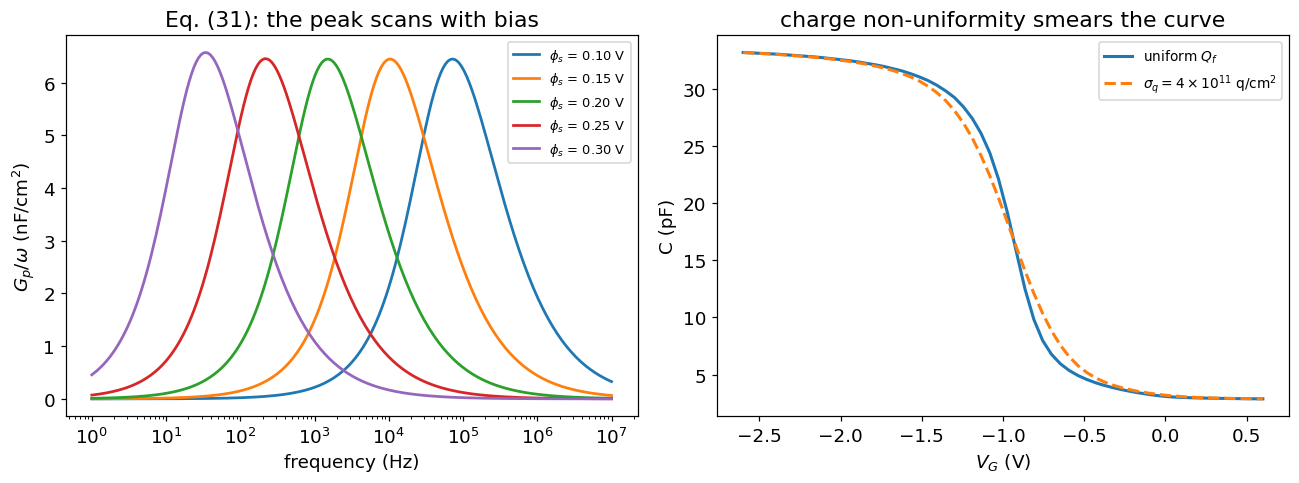

In [15]:
# --- the conductance peak, computed from the full branch model ---
Dit_flat = lambda E: np.full_like(np.asarray(E, float), 1e11)
freq = np.logspace(0, 7, 220)
omega_f = 2*np.pi*freq

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
for ps, c in zip((0.10, 0.15, 0.20, 0.25, 0.30), ['C0','C1','C2','C3','C4']):
    br = cgv.interface_branch_admittance(omega_f, ps, Dit_flat, NA_demo, 0.0)
    Gp = cgv.interface_conductance_parallel(br)          # Eqs. (29)-(31)
    ax[0].semilogx(freq, Gp/omega_f*1e9, lw=1.8, color=c,
                   label=rf'$\phi_s$ = {ps:.2f} V')
ax[0].set_xlabel('frequency (Hz)')
ax[0].set_ylabel(r'$G_p/\omega$ (nF/cm$^2$)')
ax[0].set_title('Eq. (31): the peak scans with bias')
ax[0].legend(fontsize=8.5)

# --- what a fluctuating Q_f does to the curve ---
sig_q = 4e11*cgv.Q
Vg_sm = np.linspace(-2.6, 0.6, 60)
C_sharp = np.interp(Vg_sm, Vg_id, C_id)
C_smear = np.empty_like(Vg_sm)
for i, v in enumerate(Vg_sm):
    ps_samp, wts = cgv.phi_s_distribution(v, Cox_pa, phi_ms, 0.0, sig_q,
                                          NA_demo, 0.0, n_points=15)
    Cs_samp = cgv.semiconductor_capacitance_fd(ps_samp, NA_demo, 0.0,
                                               minority_frozen=True)
    C_smear[i] = np.sum(wts*cgv.total_capacitance_series_per_area(Cox_pa, Cs_samp))*area_cm2
ax[1].plot(Vg_sm, C_sharp*1e12, lw=2, label='uniform $Q_f$')
ax[1].plot(Vg_sm, C_smear*1e12, lw=2, ls='--',
           label=r'$\sigma_q = 4\times10^{11}$ q/cm$^2$')
ax[1].set_xlabel(r'$V_G$ (V)'); ax[1].set_ylabel('C (pF)')
ax[1].set_title('charge non-uniformity smears the curve')
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

for ps in (0.10, 0.20, 0.30):
    br = cgv.interface_branch_admittance(omega_f, ps, Dit_flat, NA_demo, 0.0)
    Gw = cgv.interface_conductance_parallel(br)/omega_f
    print(f"phi_s = {ps:.2f} V -> G_p/omega peaks at {freq[np.argmax(Gw)]:.2e} Hz")

The left panel is the conductance method in one picture. Each curve is the
same interface, the same $D_{it}$, measured at a different bias. The peak
moves through four decades of frequency as the surface potential changes
by 0.2 V, because the time constant $\tau_p = 1/(\sigma_p v_{th} p_s)$
follows the surface hole density, and that is exponential in $\phi_s$.
Reading the peak *frequency* at each bias maps the trap time constant
through the gap; reading the peak *height* gives $D_{it}$ there.

The right panel is the warning that goes with it. A film whose fixed
charge varies by $4\times10^{11}$ q/cm$^{-2}$ across the gate produces a
visibly gentler transition, and nothing about the shape says the cause was
non-uniformity rather than interface traps. Two independent measurements -
or a smaller gate - are the only way to tell them apart.

## 18. What ruins a real measurement, and how do you know?

Three distinct non-idealities. They are commonly confused with each
other, and telling them apart is the actual skill this section teaches.

**Series resistance.** Contact and substrate spreading resistance distort
both $C_m$ and $G_m$, worst in strong accumulation at high frequency,
where the device looks almost purely resistive. Extract it there
[[4]](#ref4):

$$
R_s = \frac{(G/\omega C)^2}{\left[1+(G/\omega C)^2\right]G} \tag{32}
$$

then correct the rest of the sweep:

$$
a_R = G_m - \left(G_m^2+(\omega C_m)^2\right)R_s,\qquad
C_{\text{adj}} = \frac{\left(G_m^2+(\omega C_m)^2\right)C_m}{a_R^2+(\omega C_m)^2}
\tag{33}
$$

Left uncorrected, $R_s$ can make even $C_{\text{ox}}$ itself read low.

**Sweep-rate artefacts.** Already met in Sec. 6 as deep depletion: a bias
swept faster than the minority-carrier generation lifetime never reaches
the equilibrium LF curve.

**Mobile ionic charge.** Sodium or potassium ions drifting under bias (or
worse, under bias-temperature stress) shift $V_{FB}$ between a forward
and a reverse sweep - hysteresis. The shift gives the mobile sheet
density directly:

$$
\Delta N_m = -\frac{C_{\text{ox}}\Delta V_{FB}}{qA} \tag{34}
$$

The minus sign matters: positive mobile ions (Na$^+$, K$^+$) that drift to
the oxide-semiconductor interface between the forward and reverse sweep
make $V_{FB}$ *more negative* on the reverse sweep - the same relationship
as Eq. (9), where a more positive $Q_{\text{eff}}$ pulls $V_{FB}$ down.
Dropping the sign would report a negative ion density for a real,
physically positive contamination level.

**These three do not look alike, and should not be confused.** Series
resistance distorts the curve's shape at a fixed bias history. A
sweep-rate artefact changes the inversion plateau, not the depletion
slope. Mobile-ion hysteresis shifts the *whole curve* sideways, by a
different amount on the way up than on the way down, and is the only one
of the three that depends on sweep direction at all.


Delta V_FB = -0.350 V  ->  mobile ion density = 7.543e+11 cm^-2


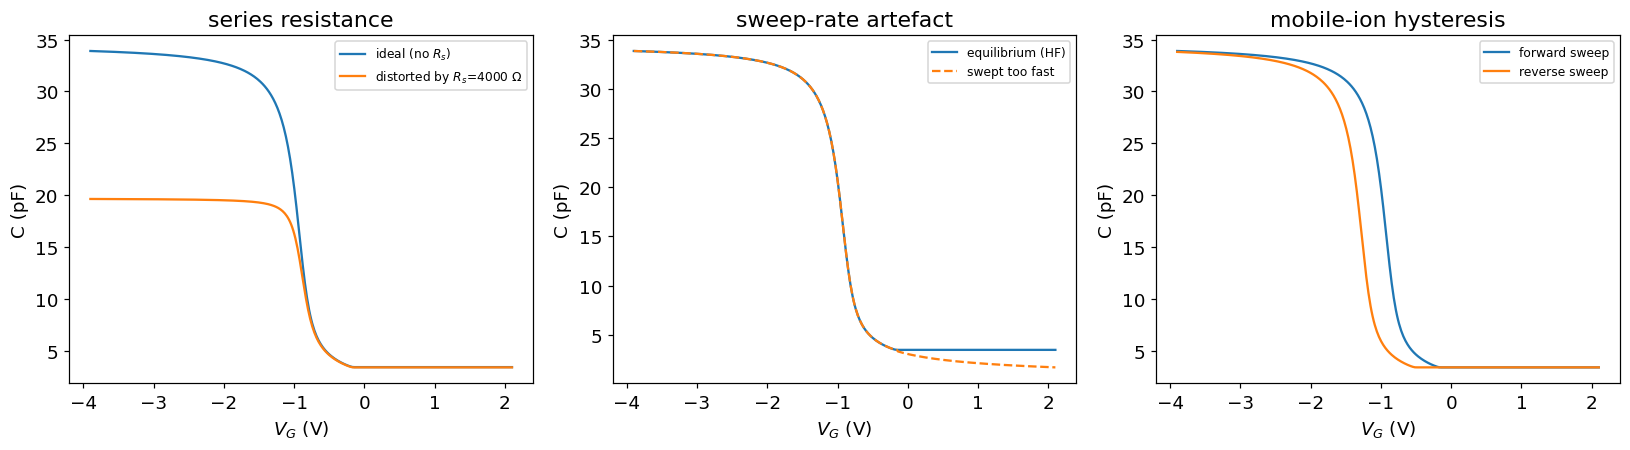

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

# --- series resistance ---
Rs_true = 4000.0   # a poorly contacted wafer; see the note below
f_test = 1e6
omega_t = 2*np.pi*f_test
Cm_ideal = C_hf  # reuse the Sec. 6 HF curve as the "ideal" device
Gm_ideal = np.full_like(Cm_ideal, 1e-9)
Zmeas = Rs_true + 1/(Gm_ideal + 1j*omega_t*Cm_ideal)
Ymeas = 1/Zmeas
Gm_meas, Cm_meas = Ymeas.real, Ymeas.imag/omega_t
axes[0].plot(Vg, Cm_ideal*1e12, label='ideal (no $R_s$)')
axes[0].plot(Vg, Cm_meas*1e12, label=f'distorted by $R_s$={Rs_true:.0f} $\Omega$')
axes[0].set_xlabel('$V_G$ (V)'); axes[0].set_ylabel('C (pF)')
axes[0].set_title('series resistance'); axes[0].legend(fontsize=8)

# --- deep depletion (sweep rate) ---
axes[1].plot(Vg, C_hf*1e12, label='equilibrium (HF)')
axes[1].plot(Vg, C_dd*1e12, ls='--', label='swept too fast')
axes[1].set_xlabel('$V_G$ (V)'); axes[1].set_ylabel('C (pF)')
axes[1].set_title('sweep-rate artefact'); axes[1].legend(fontsize=8)

# --- mobile-ion hysteresis ---
delta_VFB = -0.35
C_fwd, C_rev = cgv.synthetic_hysteresis_sweep(Vg, area_cm2, tox_nm, Na, 'p', VFB, delta_VFB)
axes[2].plot(Vg, C_fwd*1e12, label='forward sweep')
axes[2].plot(Vg, C_rev*1e12, label='reverse sweep')
axes[2].set_xlabel('$V_G$ (V)'); axes[2].set_ylabel('C (pF)')
axes[2].set_title('mobile-ion hysteresis'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

Nm = cgv.mobile_charge_from_hysteresis(delta_VFB, Cox, area_cm2)
print(f"Delta V_FB = {delta_VFB:.3f} V  ->  mobile ion density = {Nm:.3e} cm^-2")


## 19. Assumptions and limitations

The models here are deliberately simple. They assume:

- **one dimension and a uniform surface**, with no lateral variation in
  doping, oxide thickness, or trap density under the gate.
- **Boltzmann statistics and complete ionisation** in Secs. 1-13. Secs.
  14-17 drop both, and the comparison there shows the cost: under 1% in
  depletion at $10^{16}$ cm$^{-3}$, but 6-10% in accumulation and strong
  inversion, and much worse once the doping is degenerate.
- **the depletion approximation**, used only as a cross-check (Eq. 6) -
  the working equations use the exact $Q_{sc}(\phi_s)$ of Eq. (3)
  throughout, but that formula itself still assumes a classical,
  non-degenerate semiconductor.
- **a single-time-constant conductance model** (Eq. 18) in Sec. 13.
  Sec. 17 replaces it with the full multi-branch admittance of Eqs.
  (29)-(31), integrated over the gap; what neither includes is the
  band-bending-fluctuation statistics of Nicollian and Brews
  [[3]](#ref3), which broadens the peak further again.
- **no quantum-mechanical correction to inversion-layer capacitance**,
  which matters for oxides a few nanometres thick on real modern
  devices - this notebook's 10 nm worked example is comfortably in the
  classical regime, but production CMOS gate oxides are not.
- **small-signal AC amplitude** throughout, so every capacitance and
  conductance is a true differential quantity, not a large-signal
  average.
- **teaching-grade parameter values** (silicon constants, mobility,
  doping, oxide charge) - realistic in shape and scale, not measured on
  any specific device. The two halves of the notebook are each internally
  consistent but use different intrinsic densities: Secs. 1-13 take the
  tabulated $n_i = 9.65\times10^{9}$ cm$^{-3}$, while the parabolic-band
  DOS of Sec. 14 implies $1.16\times10^{10}$. Do not mix them.
- **the depletion approximation in the profile forward model** (Eq. 14),
  which has no Debye smearing in it, so the recovered implant in Sec. 9
  is slightly sharper than a real measurement would give.

They are sufficient to explain what a C-V/G-V sweep contains, why the
same algebra spans a MOS capacitor and a bare Schottky diode, and how a
frequency sweep separates a reactive response from a dissipative one.
Quantitative process-control work needs measured silicon parameters, the
full statistical conductance theory, and - for thin oxides - a
quantum-corrected inversion capacitance model.

**And one thing that is not an assumption but a definition:** every
number in this notebook follows the sign convention set in Sec. 3. Any
comparison with the literature has to start by checking which convention
the other source used - Eq. (12)'s absolute value exists specifically
because this trips people up.


## Summary of equations

| # | Equation | Meaning | Source |
|---|---|---|---|
| (1) | $C_{\text{ox}} = \varepsilon_{\text{ox}}A/t_{\text{ox}}$ | oxide capacitance | [[7]](#ref7) |
| (2) | $\phi_F = V_t\ln(N_A/n_i)$ | bulk Fermi potential | [[7]](#ref7) |
| (3) | $Q_{sc}(\phi_s) = -\varepsilon_sE_s$ | exact semiconductor space charge | [[5]](#ref5)[[9]](#ref9) |
| (4) | $C_s(\phi_s) = -dQ_{sc}/d\phi_s$ | differential semiconductor capacitance | [[5]](#ref5) |
| (5) | $L_D = \sqrt{\varepsilon_sV_t/(qN)}$ | Debye length | [[1]](#ref1) |
| (6) | $W\approx\sqrt{2\varepsilon_s\phi_s/(qN)}$ | depletion approximation (cross-check) | [[7]](#ref7) |
| (7) | $C = C_{\text{ox}}C_s/(C_{\text{ox}}+C_s)$ | series combination | [[2]](#ref2) |
| (8) | $V_G = V_{FB}+\phi_s-Q_{sc}/C_{\text{ox}}$ | charge balance | [[2]](#ref2) |
| (9) | $V_{FB} = \phi_{ms}-Q_{\text{eff}}/C_{\text{ox}}$ | flat-band voltage | [[2]](#ref2) |
| (10) | $Q_{\text{eff}} = C_{\text{ox}}(\phi_{ms}-V_{FB})$ | effective oxide charge | [[2]](#ref2) |
| (11) | $V_T = V_{FB}+s[\ldots]+s\cdot2\lvert\phi_F\rvert$ | threshold voltage | [[6]](#ref6) |
| (12) | $N(W) = 2/(q\varepsilon_sA^2\lvert d(1/C^2)/dV\rvert)$ | doping profile | [[1]](#ref1) |
| (13) | $W = \varepsilon_sA(1/C-1/C_{\text{ox}})$ | depth from measured C | [[1]](#ref1) |
| (14) | $Q_{dep}=q\!\int_0^W\! N dx$, $\phi_s=\frac{q}{\varepsilon_s}\!\int_0^W\! xN dx$ | C-V from an arbitrary $N(x)$ | [[1]](#ref1) |
| (15) | $1/C^2 = 2(V_{bi}-V)/(q\varepsilon_sA^2N)$ | Mott-Schottky (no oxide) | [[1]](#ref1) |
| (16) | $Y_m = G_m+j\omega C_m$ | measured admittance | [[3]](#ref3) |
| (17) | $G_p/\omega = \omega C_{\text{ox}}^2G_m/[G_m^2+\omega^2(C_{\text{ox}}-C_m)^2]$ | series-to-parallel transform | [[3]](#ref3) |
| (18) | $G_p/\omega = qD_{it}A\,\omega\tau_{it}/(1+(\omega\tau_{it})^2)$ | single-level conductance peak | [[3]](#ref3) |
| (19) | $\tau_p = 1/(c_pN_A)$ | capture time constant | [[3]](#ref3) |
| (20) | $n = N_c\mathcal{F}_{1/2}((E_F-E_c)/kT)$ | Fermi-Dirac carrier density | [[10]](#ref10) |
| (21) | $\mathcal{F}_j(\eta)=\frac{1}{\Gamma(j+1)}\int_0^\infty\frac{\epsilon^j d\epsilon}{1+e^{\epsilon-\eta}}$ | Fermi-Dirac integral | [[10]](#ref10) |
| (22) | $N_A^-=N_A/[1+g_ae^{(E_A-E_F)/kT}]$ | incomplete ionisation | [[10]](#ref10) |
| (23) | $N_D^+-N_A^-+p-n=0$ | bulk charge neutrality | [[10]](#ref10) |
| (24) | $\xi_s^2=\frac{2q}{\varepsilon_s}\int_0^{\phi_s}[n-p-N_D^++N_A^-]d\phi$ | space charge, Fermi-Dirac | [[10]](#ref10) |
| (25) | $C_s=-dQ_s/d\phi_s$, minority frozen at HF | capacitance from Eq. (24) | [[10]](#ref10) |
| (26) | $V_G=\frac{\Phi_{ms}}{q}+\phi_s-\frac{Q_s+Q_{it}+(1+d/t_i)Q_f}{C_i}$ | full gate-voltage balance | [[10]](#ref10) |
| (27) | $Q_{it}=q\!\int\! D^d_{it}f_d dE-q\!\int\! D^a_{it}(1-f_d)dE$ | interface-trap charge | [[10]](#ref10)[[11]](#ref11) |
| (28) | $f_d=\frac{(\sigma_n/\sigma_p)n_1+p_s}{(\sigma_n/\sigma_p)(n_s+n_1)+(p_s+p_1)}$ | SRH trap occupancy | [[11]](#ref11) |
| (29) | $R_{ps}=V_t/(qf_tS_{p0}p_s)$, $R_{ns}=V_t/(q(1-f_t)S_{n0}n_s)$ | trap capture resistances | [[10]](#ref10)[[3]](#ref3) |
| (30) | $C_{it}=qD_{it}f_t(1-f_t)/V_t$ | trap capacitance | [[10]](#ref10) |
| (31) | $G_{dp}=\int\frac{\omega^2R_{ps}C_{it}^2\,dE}{(1+R_{ps}/R_{ns})^2+(\omega R_{ps}C_{it})^2}$ | branch conductance, integrated | [[10]](#ref10)[[3]](#ref3) |
| (32) | $R_s = (G/\omega C)^2/\{[1+(G/\omega C)^2]G\}$ | series resistance (from accumulation) | [[4]](#ref4) |
| (33) | $C_{\text{adj}}, G_{\text{adj}}$ from $a_R$ | series-resistance correction | [[4]](#ref4) |
| (34) | $\Delta N_m = -C_{\text{ox}}\Delta V_{FB}/(qA)$ | mobile ion density from hysteresis | [[2]](#ref2) |

<a id="references"></a>

## References

<a id="ref1"></a>
**[1]** P. A. Barnes, *Capacitance-Voltage (C-V) Characterization of
Semiconductors*, in Characterization of Materials, Vol. 1 (Wiley, 2012).
doi:[10.1002/0471266965.com038](https://doi.org/10.1002/0471266965.com038)

<a id="ref2"></a>
**[2]** E. H. Nicollian and J. R. Brews, *MOS (Metal Oxide Semiconductor)
Physics and Technology* (Wiley, New York, 1982). ISBN 978-0471082227.

<a id="ref3"></a>
**[3]** E. H. Nicollian and A. Goetzberger, *The Si-SiO2 Interface -
Electrical Properties as Determined by the Metal-Insulator-Silicon
Conductance Technique*, Bell Syst. Tech. J. **46**, 1055-1133 (1967).
doi:[10.1002/j.1538-7305.1967.tb01727.x](https://doi.org/10.1002/j.1538-7305.1967.tb01727.x)

<a id="ref4"></a>
**[4]** J. D. Wiley and G. L. Miller, *Series resistance effects in
semiconductor CV profiling*, IEEE Trans. Electron Devices **22**, 265-272
(1975).
doi:[10.1109/T-ED.1975.18109](https://doi.org/10.1109/T-ED.1975.18109)

<a id="ref5"></a>
**[5]** A. S. Grove, E. H. Snow, B. E. Deal and C. T. Sah, *Simple
physical model for the space-charge capacitance of
metal-oxide-semiconductor structures*, J. Appl. Phys. **35**, 2458-2460
(1964).
doi:[10.1063/1.1713760](https://doi.org/10.1063/1.1713760)

<a id="ref6"></a>
**[6]** L. M. Terman, *An investigation of surface states at a
silicon/silicon oxide interface employing metal-oxide-silicon diodes*,
Solid-State Electronics **5**, 285-299 (1962).
doi:[10.1016/0038-1101(62)90111-9](https://doi.org/10.1016/0038-1101(62)90111-9)

<a id="ref7"></a>
**[7]** S. M. Sze and K. K. Ng, *Physics of Semiconductor Devices*, 3rd
ed. (Wiley, Hoboken, 2007).
doi:[10.1002/0470068329](https://doi.org/10.1002/0470068329)

<a id="ref8"></a>
**[8]** D. K. Schroder, *Semiconductor Material and Device
Characterization*, 3rd ed. (Wiley, Hoboken, 2006).
doi:[10.1002/0471749095](https://doi.org/10.1002/0471749095)

<a id="ref9"></a>
**[9]** C. G. B. Garrett and W. H. Brattain, *Physical theory of
semiconductor surfaces*, Phys. Rev. **99**, 376-387 (1955).
doi:[10.1103/PhysRev.99.376](https://doi.org/10.1103/PhysRev.99.376)

<a id="ref10"></a>
**[10]** C. N. Berglund, *Surface states at steam-grown silicon-silicon
dioxide interfaces*, IEEE Trans. Electron Devices **13**, 701-705 (1966).
doi:[10.1109/T-ED.1966.15827](https://doi.org/10.1109/T-ED.1966.15827)

<a id="ref10"></a>
**[10]** R. Seiwatz and M. Green, *Space charge calculations for
semiconductors*, J. Appl. Phys. **29**, 1034 (1958).
doi:[10.1063/1.1723358](https://doi.org/10.1063/1.1723358)

<a id="ref11"></a>
**[11]** W. Shockley and W. T. Read, *Statistics of the recombinations of
holes and electrons*, Phys. Rev. **87**, 835-842 (1952).
doi:[10.1103/PhysRev.87.835](https://doi.org/10.1103/PhysRev.87.835)
